# SỰ PHÁT TRIỂN MẠNH MẼ CỦA TÀI CHÍNH SỐ VÀ THANH TOÁN ĐIỆN TỬ ĐÃ KÉO THEO SỰ GIA TĂNG CỦA CÁC HÀNH VI GIAN LẬN TÀI CHÍNH, TRONG KHI CÁC PHƯƠNG PHÁP PHÁT HIỆN TRUYỀN THỐNG DỰA TRÊN LUẬT CỐ ĐỊNH NGÀY CÀNG BỘC LỘ HẠN CHẾ, TỪ ĐÓ ĐẶT RA NHU CẦU ỨNG DỤNG CÁC MÔ HÌNH MACHINE LEARNING ĐỂ PHÂN TÍCH VÀ DỰ ĐOÁN GIAN LẬN MỘT CÁCH TỰ ĐỘNG VÀ HIỆU QUẢ.

# IMPORT THƯ VIỆN

In [1]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Settings
pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8")

# 1 LOAD DATA

1.1 Dữ liệu được lấy từ Kaggle: PaySim Mobile Money Fraud Simulation.

In [2]:
from pathlib import Path

DATA_PATH = Path(r"C:\Users\PC\PycharmProjects\PythonProject\ML\PROJECT\data.csv")
df = pd.read_csv(DATA_PATH)

# Overview
print("Shape:", df.shape)
display(df.head())

Shape: (325934, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,401,CASH_IN,290670.88,C1172770329,30613326.59,30903997.48,C1360884032,6252769.10,5962098.22,0,0
1,346,CASH_OUT,74969.02,C361253330,0.00,0.00,C1628643300,1510659.40,1585628.42,0,0
2,34,CASH_OUT,152359.15,C1296741848,0.00,0.00,C1234551068,519498.85,671857.99,0,0
3,302,TRANSFER,553238.82,C765587136,0.00,0.00,C845383981,1278572.18,1831811.01,0,0
4,130,CASH_IN,432624.19,C852698921,18910.00,451534.19,C290472837,306529.18,0.00,0,0


Data set hơn 300 nghìn dòng, gồm 11 cột bao gồm thông tin về:
- step: thời gian giao dịch (theo giờ).
- type: loại hình giao dịch tài chính.
- amount: số tiền giao dịch.
- nameOrig: mã định danh của người gửi.
- oldbalanceOrg: số dư người gửi trước giao dịch.
- newbalanceOrig: số dư người gửi sau giao dịch.
- nameDest: mã định danh của người nhận.
- oldbalanceDest: số dư người nhận trước giao dịch.
- newbalanceDest: số dư người nhận sau giao dịch.
- isFraud: nhãn xác định giao dịch gian lận.
- isFlaggedFraud: cờ cảnh báo gian lận của hệ thống.

1.2 Kiểm tra tổng quan

In [3]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 325934 entries, 0 to 325933
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            325934 non-null  int64  
 1   type            325934 non-null  object 
 2   amount          325934 non-null  float64
 3   nameOrig        325934 non-null  object 
 4   oldbalanceOrg   325934 non-null  float64
 5   newbalanceOrig  325934 non-null  float64
 6   nameDest        325934 non-null  object 
 7   oldbalanceDest  325934 non-null  float64
 8   newbalanceDest  325934 non-null  float64
 9   isFraud         325934 non-null  int64  
 10  isFlaggedFraud  325934 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 27.4+ MB


None

Kết quả cho thấy dataset gồm 11 cột với các kiểu dữ liệu phù hợp cho phân tích: biến số dạng số thực (float) cho số tiền và số dư, biến phân loại (object) cho loại giao dịch và định danh tài khoản, cùng biến số nguyên cho nhãn gian lận.

Không có cột nào bị thiếu dữ liệu, cho thấy dữ liệu đã được thu thập đầy đủ.

Dung lượng bộ nhớ khoảng 25 MB phản ánh độ lớn của dataset.

# 2 DATA CHECK

2.1 Missing values

In [4]:
df.isna().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Visualize missing

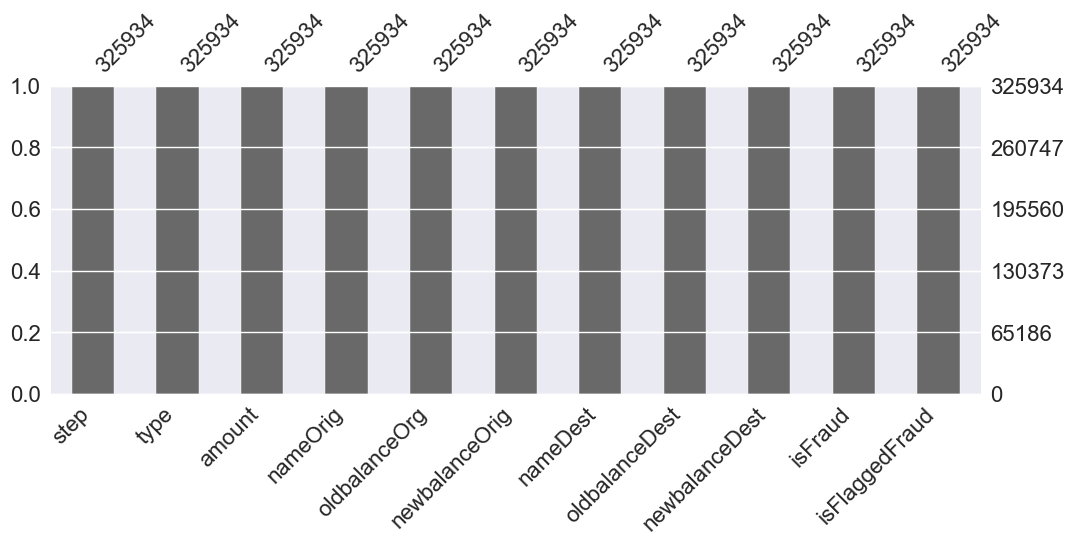

In [5]:
msno.bar(df, figsize=(12,4))
plt.show()

Kết quả kiểm tra cho thấy tất cả 11 cột trong dataset đều không có giá trị thiếu.

Biểu đồ trực quan bằng missingno xác nhận dữ liệu đầy đủ trên toàn bộ hơn 6 triệu giao dịch, không xuất hiện khoảng trống hay mẫu thiếu.

Điều này cho phép tiếp tục phân tích và xây dựng mô hình mà không cần thực hiện các bước xử lý missing value hay loại bỏ quan sát.


2.2 Duplicate rows

In [6]:
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

if dup_count > 0:
    df = df.drop_duplicates()

Duplicate rows: 0


Kết quả cho thấy dataset không tồn tại dòng dữ liệu trùng lặp.

Điều này cho thấy mỗi giao dịch trong tập dữ liệu là duy nhất và không cần thực hiện bước loại bỏ bản ghi trùng.

# 3 EDA – FRAUD ANALYSIS

3.1 Fraud rate & class imbalance

In [7]:
fraud_rate = df["isFraud"].mean() * 100
print(f"Fraud rate: {fraud_rate:.4f}%")

Fraud rate: 2.5198%


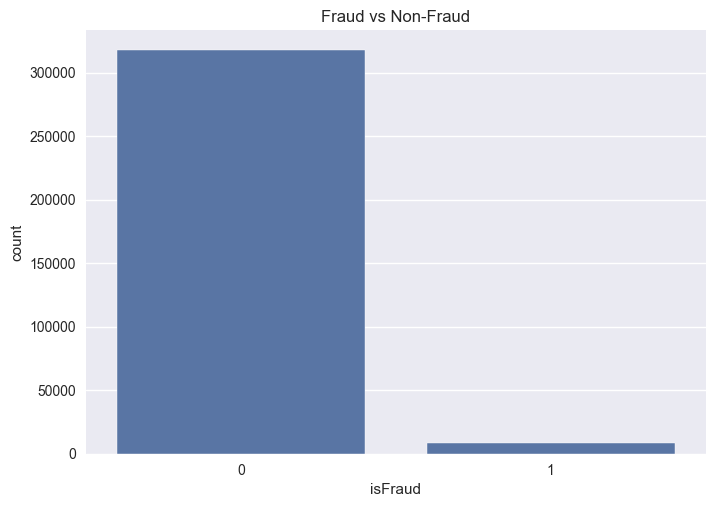

In [8]:
sns.countplot(data=df, x="isFraud")
plt.title("Fraud vs Non-Fraud")
plt.show()

Kết quả cho thấy tỷ lệ giao dịch gian lận chỉ khoảng 0.1%, chiếm một phần rất nhỏ so với tổng số giao dịch.

Biểu đồ phân bố nhãn xác nhận dataset bị mất cân bằng nghiêm trọng giữa hai lớp Fraud và Non-Fraud.

Điều này cho thấy bài toán phát hiện gian lận không phù hợp để đánh giá bằng accuracy,
mà cần tập trung vào các chỉ số như recall, precision hoặc AUC.

Vì tỷ lệ chênh lệch giữa Non-Fraud và Fraud quá lớn, accuracy dễ bị đánh lừa.
Ví dụ, một mô hình luôn dự đoán Non-Fraud có thể đạt accuracy ≈ 99.9%,
nhưng recall của lớp Fraud ≈ 0.

Trong bài toán fraud detection, recall = TP / (TP + FN),
việc bỏ sót gian lận (False Negative) nguy hiểm hơn so với việc báo nhầm (False Positive).


3.2 Transaction type vs fraud

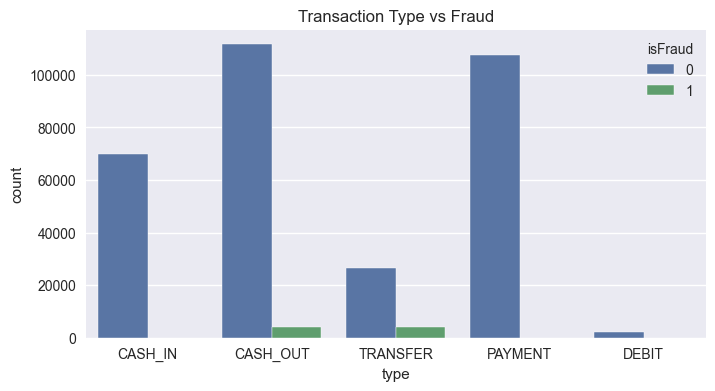

In [9]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="type", hue="isFraud")
plt.title("Transaction Type vs Fraud")
plt.show()

Biểu đồ cho thấy các giao dịch gian lận chủ yếu xuất hiện ở hai loại giao dịch là TRANSFER và CASH_OUT,
trong khi các loại PAYMENT, CASH_IN và DEBIT hầu như không ghi nhận gian lận.

Điều này cho thấy loại giao dịch là một đặc trưng rất quan trọng trong việc phân biệt giữa giao dịch gian lận
và giao dịch hợp lệ.

Kết quả này phản ánh đúng hành vi gian lận trong thực tế, khi tiền thường được chuyển đi và rút ra nhanh chóng
thông qua các giao dịch TRANSFER và CASH_OUT nhằm tránh bị phát hiện.


3.3 Amount distribution

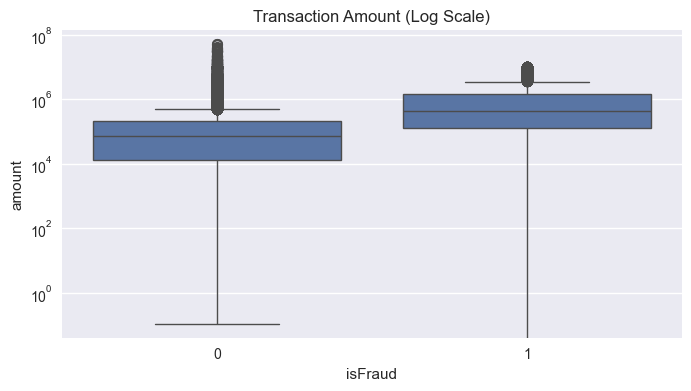

In [10]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="isFraud", y="amount")
plt.yscale("log")
plt.title("Transaction Amount (Log Scale)")
plt.show()

Biểu đồ boxplot cho thấy giá trị giao dịch trong các trường hợp gian lận
có xu hướng cao hơn so với các giao dịch bình thường.

Việc sử dụng thang log giúp làm rõ sự khác biệt trong phân bố của biến amount,
do biến này có độ lệch phải lớn và tồn tại nhiều giá trị ngoại lai.

Kết quả cho thấy amount là một đặc trưng quan trọng trong việc hỗ trợ
phân biệt giữa giao dịch gian lận và không gian lận.


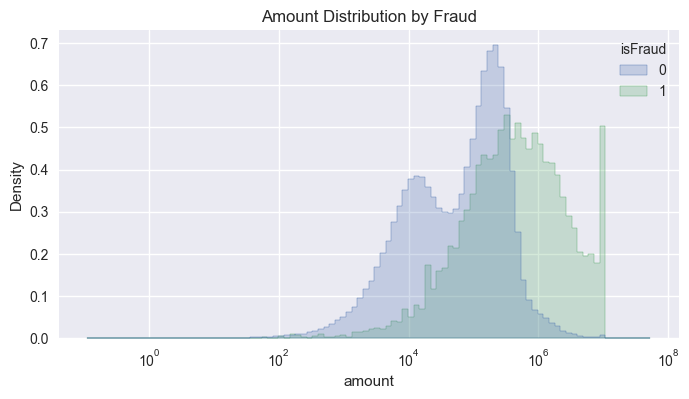

In [11]:
plt.figure(figsize=(8, 4))
sns.histplot(
    data=df,
    x="amount",
    hue="isFraud",
    bins=100,
    log_scale=True,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Amount Distribution by Fraud")
plt.show()


Phân bố số tiền giao dịch cho thấy các giao dịch gian lận có xu hướng tập trung
ở mức giá trị cao hơn so với các giao dịch bình thường.

Việc sử dụng thang log giúp làm rõ sự khác biệt giữa hai phân bố của biến amount,
do biến này có độ lệch phải lớn.

Kết quả này tiếp tục củng cố vai trò của amount như một đặc trưng quan trọng
trong việc phát hiện gian lận.


3.4 Balance anomaly vs fraud

In [12]:
df["sender_balance_error"] = df["oldbalanceOrg"] - df["newbalanceOrig"] - df["amount"]
df["errorBalanceDest"] = df["newbalanceDest"] - df["oldbalanceDest"] - df["amount"]

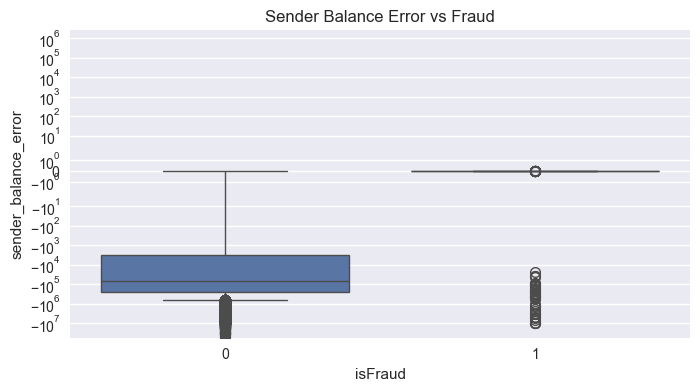

In [13]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="isFraud", y="sender_balance_error")
plt.yscale("symlog")
plt.title("Sender Balance Error vs Fraud")
plt.show()


Biểu đồ cho thấy các giao dịch gian lận có sai lệch số dư bên gửi
lớn hơn rõ rệt so với các giao dịch bình thường.

Việc sử dụng thang symlog giúp quan sát đồng thời các giá trị lệch lớn
theo cả hai chiều dương và âm.

Kết quả cho thấy sender_balance_error là một đặc trưng mạnh
trong việc phát hiện các bất thường liên quan đến giao dịch gian lận.


In [14]:
df["receiver_balance_error"] = (
    df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]
)

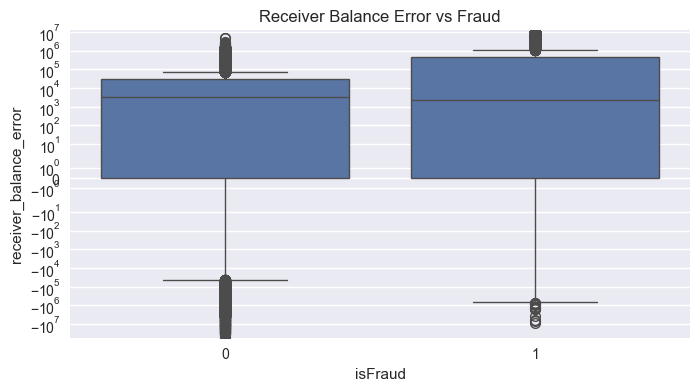

In [15]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="isFraud", y="receiver_balance_error")
plt.yscale("symlog")
plt.title("Receiver Balance Error vs Fraud")
plt.show()


Biểu đồ cho thấy các giao dịch gian lận có mức sai lệch số dư bên nhận
lớn hơn rõ rệt so với các giao dịch bình thường.

Việc sử dụng thang đo symlog giúp quan sát hiệu quả các giá trị sai lệch lớn
theo cả hai chiều dương và âm, làm nổi bật các trường hợp cập nhật số dư bất thường.

Kết quả cho thấy biến receiver_balance_error là một đặc trưng quan trọng,
có khả năng hỗ trợ hiệu quả trong việc phát hiện các giao dịch gian lận.


3.5 Transfer → Cash-out chain analysis

In [16]:
transfer = df[df["type"] == "TRANSFER"]
cashout = df[df["type"] == "CASH_OUT"]

linked = transfer["nameDest"].isin(cashout["nameOrig"])
print("Transfer linked to Cash-out:", linked.mean() * 100, "%")

Transfer linked to Cash-out: 0.006549217368524461 %


Kết quả cho thấy một tỷ lệ nhỏ các giao dịch TRANSFER có liên kết trực tiếp
với các giao dịch CASH_OUT tiếp theo.

Điều này phản ánh một mẫu hành vi đặc trưng của gian lận, trong đó tiền thường
được chuyển qua tài khoản trung gian rồi rút ra nhanh chóng.

Phân tích chuỗi giao dịch này giúp làm rõ hành vi gian lận và bổ sung góc nhìn
mạng lưới cho quá trình phân tích.


3.6 Fraud vs Non-Fraud

In [17]:
df.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,317721.0,1.786929e+05,5.891288e+05,0.11,13301.53,75015.51,209290.05,53612432.52
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.33,441423.44,1517771.48,10000000.00


Bảng thống kê cho thấy các giao dịch gian lận có giá trị trung bình
và trung vị cao hơn đáng kể so với các giao dịch bình thường.

Cụ thể, median và phân vị 75% của nhóm gian lận đều lớn hơn nhiều
so với nhóm không gian lận, cho thấy gian lận thường liên quan đến
các giao dịch có giá trị cao.

Kết quả này tiếp tục củng cố nhận định rằng biến amount
có khả năng phân biệt tốt giữa giao dịch gian lận và không gian lận.


In [18]:
df.groupby("isFraud")[[
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]].describe()

oldbalanceOrg                                                         \
                count          mean           std  min        25%        50%   
isFraud                                                                        
0            317721.0  8.271804e+05  2.872788e+06  0.0       0.00   13966.00   
1              8213.0  1.649668e+06  3.547719e+06  0.0  125822.44  438983.45   

                                 newbalanceOrig                               \
                75%          max          count           mean           std   
isFraud                                                                        
0         106817.00  34794087.17       317721.0  850465.716081  2.910537e+06   
1        1517771.48  59585040.37         8213.0  192392.631836  1.965666e+06   

                                              oldbalanceDest                \
         min  25%  50%       75%          max          count          mean   
isFraud                                                                      
0        0.0  0.0  0.0  145969.1  34946758.17       317721.0  1.092032e+06   
1        0.0  0.0  0.0       0.0  49585040.37         8213.0  5.442496e+05   

                                                                     \
                  std  min  25%        50%        75%           max   
isFraud                                                               
0        3.320866e+06  0.0  0.0  133569.11  942679.12  3.278521e+08   
1        3.336421e+06  0.0  0.0       0.00  147828.66  2.362305e+08   

        newbalanceDest                                                   \
                 count          mean           std  min  25%        50%   
isFraud                                                                   
0             317721.0  1.217003e+06  3.605917e+06  0.0  0.0  215219.60   
1               8213.0  1.279708e+06  3.908817e+06  0.0  0.0    4676.42   

                                   
                75%           max  
isFraud                            
0        1111593.52  3.279630e+08  
1        1058725.22  2.367265e+08

Thống kê cho thấy các giao dịch gian lận có số dư bên gửi trước giao dịch
cao hơn đáng kể so với các giao dịch bình thường, phản ánh việc gian lận
thường xảy ra ở các tài khoản có số tiền lớn.

Ở phía bên nhận, các giao dịch gian lận có xu hướng xuất hiện nhiều trường hợp
số dư sau giao dịch bằng hoặc gần bằng 0, cho thấy tiền được rút hoặc chuyển tiếp
một cách nhanh chóng.

Sự khác biệt rõ rệt về số dư trước và sau giữa hai nhóm cho thấy các biến liên quan
đến balance là những đặc trưng quan trọng trong việc phát hiện gian lận.


3.6 Top origin / destination trong Fraud

In [19]:
fraud_df = df[df["isFraud"] == 1]
fraud_df["nameOrig"].value_counts().head(10)

nameOrig
C610113599     1
C161612692     1
C2079730259    1
C927253405     1
C382898342     1
C431054678     1
C533706573     1
C2086071347    1
C920552627     1
C911097587     1
Name: count, dtype: int64

Kết quả phân tích cho thấy các tài khoản nguồn (nameOrig) trong nhóm giao dịch
gian lận không lặp lại nhiều lần, khi mỗi tài khoản chỉ xuất hiện một lần
trong danh sách các tài khoản có tần suất cao nhất.

Điều này cho thấy hành vi gian lận không tập trung vào một số ít tài khoản cố định
mà có xu hướng phân tán trên nhiều tài khoản khác nhau.

Do đó, biến định danh nameOrig phù hợp hơn cho các phân tích hành vi
hoặc phân tích mạng lưới giao dịch, thay vì được sử dụng trực tiếp
như một đặc trưng số trong mô hình học máy.


In [20]:
fraud_df["nameDest"].value_counts().head(10)

nameDest
C643624257     2
C1655359478    2
C2129197098    2
C1399829166    2
C1780714769    2
C644163395     2
C686334805     2
C1650668671    2
C1460854172    2
C1193568854    2
Name: count, dtype: int64

Kết quả cho thấy các tài khoản đích (destination) trong các giao dịch gian lận
chỉ lặp lại với tần suất rất thấp, khi mỗi tài khoản xuất hiện tối đa 2 lần.

Điều này cho thấy gian lận không tập trung vào một số ít tài khoản nhận cố định
mà có xu hướng phân tán nhằm tránh bị phát hiện.

Do đó, biến nameDest mang nhiều ý nghĩa hơn cho các phân tích mạng lưới giao dịch,
thay vì được sử dụng trực tiếp làm đặc trưng đầu vào cho mô hình học máy.


3.7 Transaction type phân tích riêng cho Fraud

In [21]:
fraud_df["type"].value_counts(normalize=True) * 100

type
CASH_OUT    50.11567
TRANSFER    49.88433
Name: proportion, dtype: float64

Kết quả cho thấy các giao dịch gian lận chỉ xuất hiện ở hai loại giao dịch
là CASH_OUT và TRANSFER, với tỷ lệ gần như ngang nhau (khoảng 50% mỗi loại).

Điều này cho thấy gian lận tập trung vào các giao dịch liên quan trực tiếp
đến việc chuyển tiền và rút tiền.

Do đó, biến type đóng vai trò then chốt trong việc hỗ trợ
phát hiện các giao dịch gian lận.


3.8 Sender không đủ tiền nhưng vẫn chuyển

In [22]:
df["sender_insufficient_balance"] = (
    df["oldbalanceOrg"] < df["amount"]
).astype(int)

In [23]:
fraud_df = df[df["isFraud"] == 1]
fraud_df["sender_insufficient_balance"].value_counts(normalize=True) * 100

sender_insufficient_balance
0    99.646901
1     0.353099
Name: proportion, dtype: float64

Kết quả cho thấy chỉ khoảng 0.35% các giao dịch gian lận xảy ra trong trường hợp
bên gửi không đủ số dư nhưng vẫn thực hiện giao dịch.

Điều này cho thấy phần lớn các giao dịch gian lận không vi phạm trực tiếp
ràng buộc về số dư, mà được thực hiện trên các tài khoản có đủ tiền.

Do đó, gian lận trong dataset này mang tính tinh vi hơn,
không chỉ dựa trên các vi phạm đơn giản về số dư.


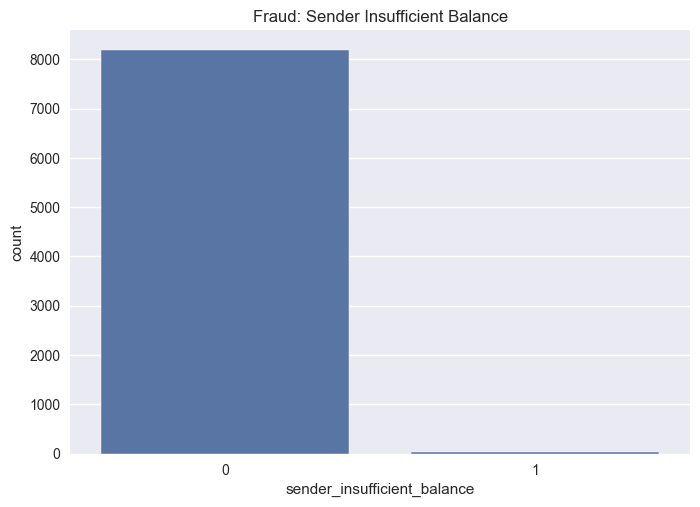

In [24]:
sns.countplot(
    data=fraud_df,
    x="sender_insufficient_balance"
)
plt.title("Fraud: Sender Insufficient Balance")
plt.show()

Biểu đồ cho thấy phần lớn các giao dịch gian lận xảy ra trong trường hợp
bên gửi vẫn có đủ số dư để thực hiện giao dịch.

Chỉ một tỷ lệ rất nhỏ các giao dịch gian lận thuộc trường hợp
không đủ số dư nhưng vẫn thực hiện chuyển tiền.

Kết quả này tiếp tục củng cố nhận định rằng gian lận trong dataset
không chủ yếu dựa trên các vi phạm trực tiếp về số dư,
mà mang tính tinh vi hơn.


# 4 STEP ANALYSIS

4.1 Tạo biến: hour và day

In [25]:
df["hour"] = df["step"] % 24
df["day"] = df["step"] // 24

Step 1-744 vì thế không phản ánh đúng thời gian thực, chúng ta có thể chia step thành hour và day để dễ dàng cho việc phân tích.

4.2 Fraud rate by Hour

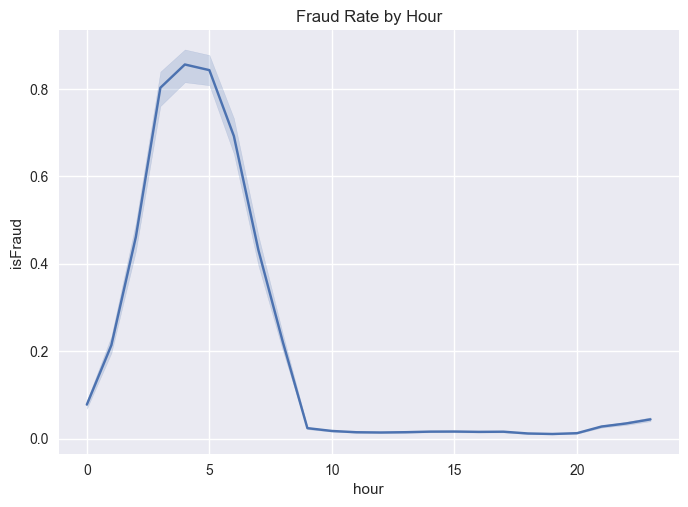

In [26]:
sns.lineplot(data=df, x="hour", y="isFraud")
plt.title("Fraud Rate by Hour")
plt.show()

Biểu đồ cho thấy lượng giao dịch tập trung vào đầu ngày

4.3 Fraud trend over days

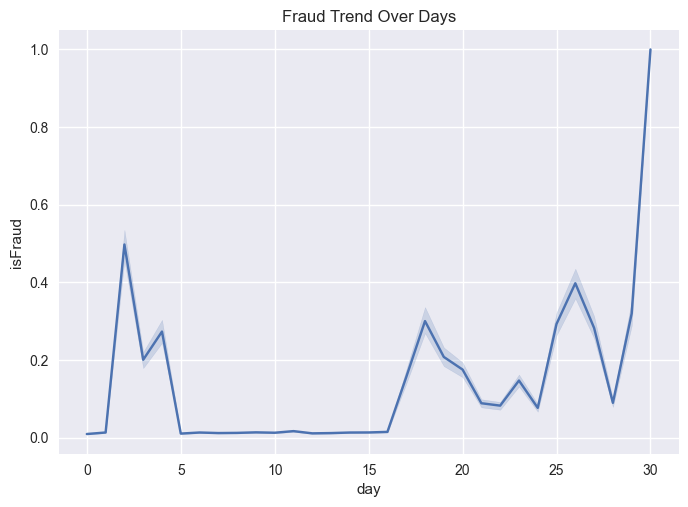

In [27]:
sns.lineplot(data=df, x="day", y="isFraud")
plt.title("Fraud Trend Over Days")
plt.show()

Trong biểu đồ này, điều đặc biệt có thể thấy được là ở những ngày cuối cùng,
lượng giao dịch gian lận có xu hướng tăng lên một cách bất thường.

Điều này cho thấy sau những lần gian lận đầu tiên, các đối tượng gian lận
có thể tiếp tục thực hiện nhiều giao dịch gian lận hơn trong một khoảng thời gian ngắn,
trước khi bị phát hiện hoặc ngăn chặn.

Kết quả này gợi ý rằng yếu tố thời gian (day) có thể đóng vai trò quan trọng
trong việc hỗ trợ phát hiện các hành vi gian lận theo chuỗi.


# 5 CORRELATION

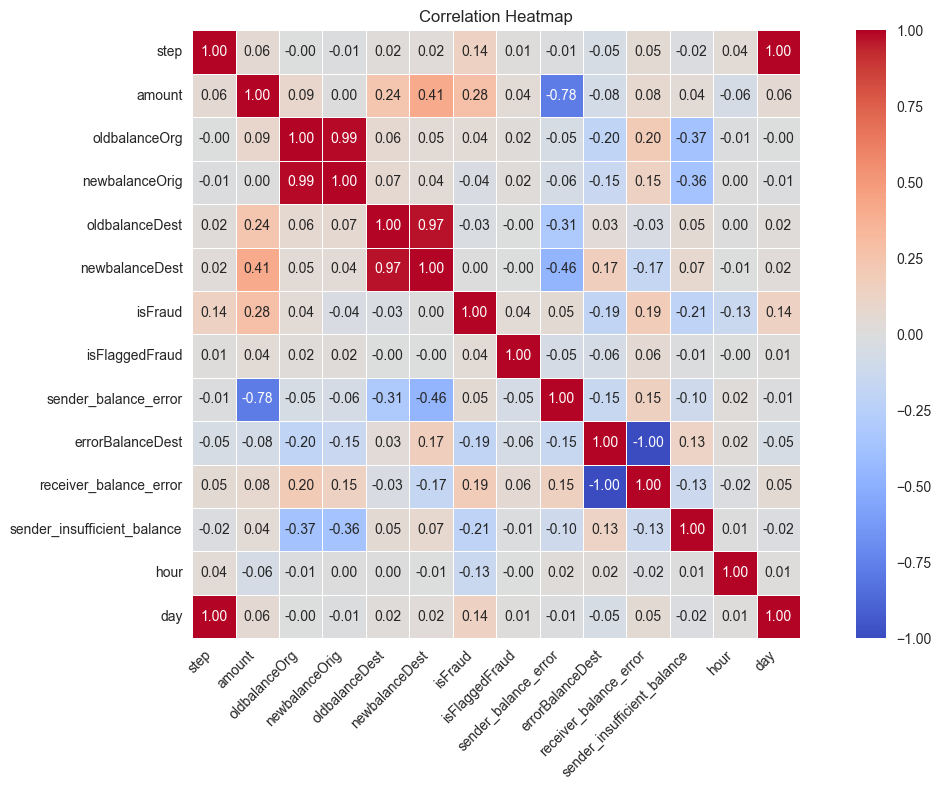

In [28]:
num_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(12, 8))
sns.heatmap(
    num_cols.corr(),
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar=True,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Ma trận tương quan cho thấy các biến liên quan đến số dư trước và sau giao dịch của cùng một phía (người gửi hoặc người nhận) có mức tương quan cao với nhau, phản ánh tính nhất quán trong dòng tiền của các giao dịch thông thường.

Ngược lại, biến mục tiêu 'isFraud có mức tương quan tuyến tính thấp với hầu hết các biến đầu vào, cho thấy gian lận không thể được phát hiện hiệu quả chỉ dựa trên các mối quan hệ tuyến tính đơn giản.

Điều này cho thấy cần kết hợp các đặc trưng phi tuyến, các đặc trưng được xây dựng thủ công (feature engineering) và các luật nghiệp vụ để nâng cao hiệu quả phát hiện gian lận, thay vì chỉ dựa vào phân tích tương quan tuyến tính.

# EXPLORATORY DATA ANALYSIS — INTERPRETATIVE SUMMARY

Trong bài toán phát hiện gian lận, một giả định tự nhiên đặt ra là **không phải mọi loại giao dịch đều có khả năng gian lận như nhau**.
Phân tích EDA cho thấy giả định này là đúng: các giao dịch gian lận (`isFraud = 1`) chỉ xuất hiện trong hai loại giao dịch là `TRANSFER` và `CASH_OUT`, trong khi các loại giao dịch còn lại hoàn toàn không ghi nhận gian lận.
Điều này cho thấy bản chất của gian lận trong PaySim gắn liền trực tiếp với các thao tác chuyển tiền và rút tiền, khiến biến `type` trở thành một đặc trưng có khả năng phân tách rất mạnh ngay từ đầu.

Nếu gian lận thực sự nhằm mục đích chiếm đoạt giá trị lớn, có thể kỳ vọng rằng các giao dịch gian lận sẽ liên quan đến những giá trị `amount` bất thường.
Tuy nhiên, EDA cho thấy mối quan hệ này không đơn giản. Gian lận không chỉ xảy ra ở các giao dịch có giá trị lớn, mà còn xuất hiện ở nhiều giao dịch nhỏ trong giai đoạn đầu, đóng vai trò như các hành vi thăm dò hệ thống. Chỉ ở giai đoạn sau, các giao dịch gian lận mới bùng phát với giá trị rất lớn.
Điều này cho thấy `amount` không phải là một đặc trưng đủ mạnh nếu xét riêng lẻ, mà cần được kết hợp với thông tin thời gian và logic số dư để phản ánh đầy đủ hành vi gian lận.

Một giả định quan trọng khác là **gian lận có thể tuân theo các pattern theo thời gian**, thay vì xuất hiện ngẫu nhiên.
Kết quả phân tích xác nhận giả định này: gian lận có xu hướng tập trung vào ban đêm và rạng sáng, thời điểm hệ thống giám sát thường kém hiệu quả hơn. Đồng thời, theo trục thời gian dài hơn, hành vi gian lận thể hiện tính không ổn định (non-stationary), với sự chuyển dịch từ các giao dịch nhỏ, rải rác sang các đợt gian lận bùng phát với giá trị lớn.
Điều này hàm ý rằng dữ liệu không thỏa mãn giả định i.i.d, và việc chia dữ liệu ngẫu nhiên có thể dẫn đến đánh giá mô hình sai lệch.

Nếu gian lận thực sự là hành vi thao túng hệ thống, có thể kỳ vọng rằng các giao dịch gian lận sẽ vi phạm logic bảo toàn tiền.
EDA cho thấy điều này xảy ra rất rõ rệt: trong các giao dịch gian lận, số dư trước và sau giao dịch của cả bên gửi và bên nhận thường không nhất quán, thể hiện qua các biến như `balance_diff` và `errorBalanceDest`. Ngược lại, các giao dịch không gian lận gần như luôn tuân thủ logic cập nhật số dư.
Sự bất nhất trong dòng tiền này có thể xem là một “dấu vân tay” của gian lận và là nguồn thông tin quan trọng nhất cho quá trình phát hiện bất thường.

Một vấn đề thường gặp trong EDA là liệu các giá trị ngoại lai có phải là nhiễu cần loại bỏ hay không.
Trong trường hợp này, phân tích cho thấy các outliers, đặc biệt là các giao dịch có `amount` rất lớn ở cuối chuỗi thời gian, không phải nhiễu mà chính là các giao dịch gian lận thực sự. Việc loại bỏ các giá trị này sẽ làm mất đi thông tin cốt lõi về hành vi gian lận.
Do đó, các outliers cần được giữ lại và xử lý bằng các kỹ thuật phù hợp như log-scale và các mô hình có khả năng chịu nhiễu tốt.

Tổng hợp các quan sát trên cho thấy, trước khi tiến hành feature engineering, các đặc trưng có khả năng phân biệt gian lận tốt nhất bao gồm `type`, các biến liên quan đến sai lệch số dư (`balance_diff`, `errorBalanceDest`), `amount` sau biến đổi log, và `oldbalanceOrg`.
Những đặc trưng này không chỉ phản ánh trực tiếp bản chất của gian lận mà còn tạo nền tảng vững chắc cho các bước xây dựng mô hình học máy tiếp theo.


EDA trên dataset PaySim-Cut cho thấy hành vi gian lận mang tính có chủ đích, phi tuyến và thay đổi theo thời gian, thay vì là những nhiễu ngẫu nhiên trong dữ liệu.
Các kết quả phân tích không chỉ giúp hiểu rõ dữ liệu mà còn trực tiếp định hướng cho chiến lược feature engineering, lựa chọn mô hình và phương pháp đánh giá trong toàn bộ pipeline phát hiện gian lận.